In [25]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings("ignore")

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

import albumentations as A
from albumentations.pytorch import ToTensorV2

import timm
import mlflow

In [24]:
!pip install -q timm albumentations mlflow onnx onnxruntime onnxscript

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 689.1/689.1 kB 10.5 MB/s eta 0:00:00 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 164.1/164.1 kB 5.7 MB/s eta 0:00:00


In [8]:
DATASET_PATH = '/kaggle/input/datasets/feyzazkefe/trashnet/dataset-resized'
# List classes
classes = sorted(os.listdir(DATASET_PATH))
print("Classes found:", classes)
print("Number of classes:", len(classes))

Classes found: ['cardboard', 'glass', 'metal', 'paper', 'plastic', 'trash']
Number of classes: 6


In [11]:
# --------------------- 2. Create metadata DataFrame ---------------------
image_paths = []
labels = []

for class_name in classes:
    class_folder = os.path.join(DATASET_PATH, class_name)
    for img_name in os.listdir(class_folder):
        if img_name.lower().endswith(('.jpg', '.jpeg', '.png')):
            image_paths.append(os.path.join(class_folder, img_name))
            labels.append(class_name)

df = pd.DataFrame({
    'image_path': image_paths,
    'label': labels,
    'class_id': pd.Categorical(labels).codes
})

print(f"\nTotal images: {len(df)}")
print("\nClass distribution:")
print(df['label'].value_counts().sort_index())


Total images: 2527

Class distribution:
label
cardboard    403
glass        501
metal        410
paper        594
plastic      482
trash        137
Name: count, dtype: int64


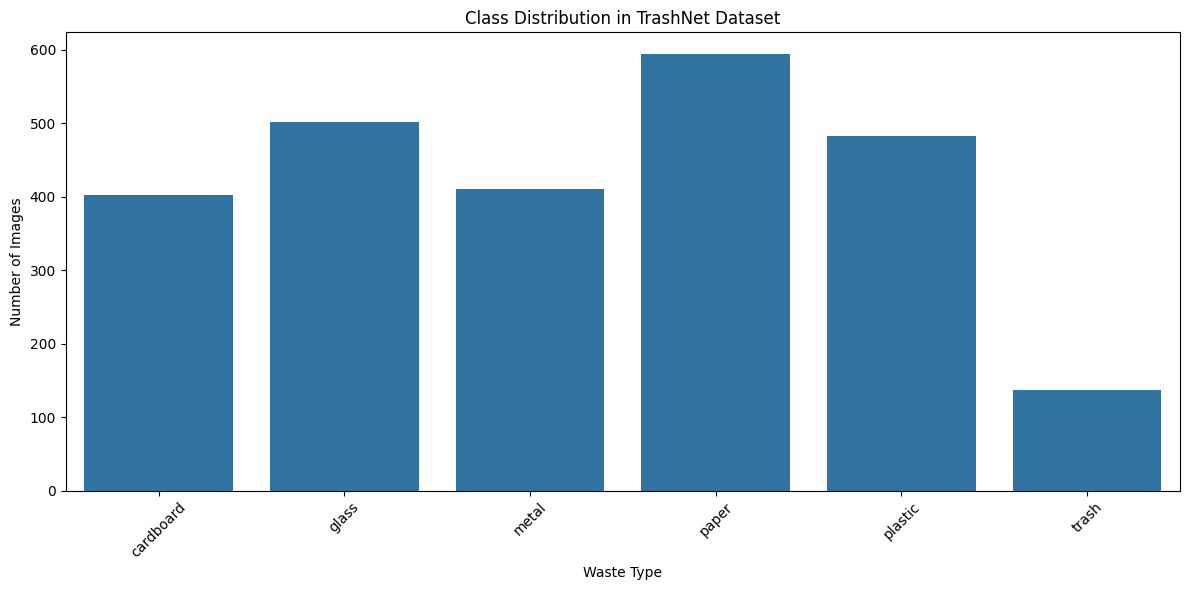

In [12]:
# --------------------- 3. EDA - Visualizations ---------------------

plt.figure(figsize=(12, 6))
sns.countplot(data=df, x='label', order=classes)
plt.title('Class Distribution in TrashNet Dataset')
plt.xlabel('Waste Type')
plt.ylabel('Number of Images')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

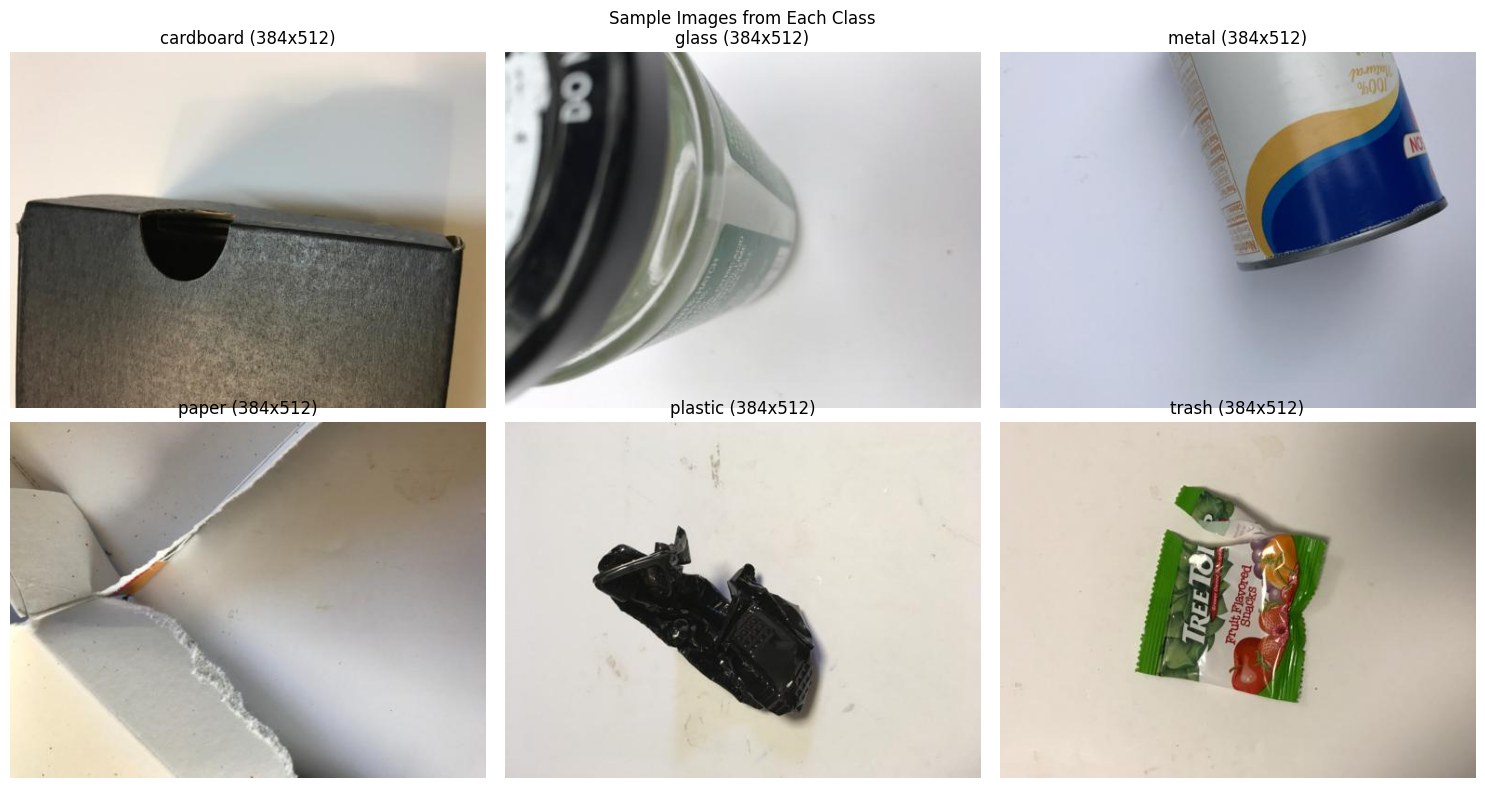

In [13]:
# Show sample images (one from each class)
plt.figure(figsize=(15, 8))
for i, class_name in enumerate(classes):
    sample_path = df[df['label'] == class_name]['image_path'].iloc[0]
    img = plt.imread(sample_path)
    plt.subplot(2, 3, i+1)
    plt.imshow(img)
    plt.title(class_name + f" ({img.shape[0]}x{img.shape[1]})")
    plt.axis('off')
plt.suptitle('Sample Images from Each Class')
plt.tight_layout()
plt.show()

In [14]:
# Basic image size statistics
sizes = []
for path in df['image_path'].sample(200):  # Sample 200 images for speed
    img = plt.imread(path)
    sizes.append(img.shape[:2])

sizes = np.array(sizes)
print(f"\nAverage image size: {sizes.mean(axis=0)[0]:.0f} x {sizes.mean(axis=0)[1]:.0f}")
print("Min size:", sizes.min(axis=0))
print("Max size:", sizes.max(axis=0))




Average image size: 384 x 512
Min size: [384 512]
Max size: [384 512]


In [15]:
# --------------------- 4. Stratified Train / Val / Test Split ---------------------

X = df['image_path'].values
y = df['label'].values

# First split: 70% train, 30% temp
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.30, stratify=y, random_state=42
)

# Second split: 15% val, 15% test (50% of temp)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, stratify=y_temp, random_state=42
)

print(f"\nFinal Split:")
print(f"Train  : {len(X_train)} images ({len(X_train)/len(df)*100:.1f}%)")
print(f"Val    : {len(X_val)} images ({len(X_val)/len(df)*100:.1f}%)")
print(f"Test   : {len(X_test)} images ({len(X_test)/len(df)*100:.1f}%)")

# Create distribution check
split_df = pd.DataFrame({
    'Train': pd.Series(y_train).value_counts(),
    'Val': pd.Series(y_val).value_counts(),
    'Test': pd.Series(y_test).value_counts()
}).fillna(0).astype(int)

print("\nClass distribution across splits:")
print(split_df)


Final Split:
Train  : 1768 images (70.0%)
Val    : 379 images (15.0%)
Test   : 380 images (15.0%)

Class distribution across splits:
           Train  Val  Test
cardboard    282   61    60
glass        350   75    76
metal        287   61    62
paper        416   89    89
plastic      337   72    73
trash         96   21    20


In [19]:
# --------------------- 5. Save splits to CSV + Download links ---------------------
train_df = pd.DataFrame({'image_path': X_train, 'label': y_train})
val_df   = pd.DataFrame({'image_path': X_val,   'label': y_val})
test_df  = pd.DataFrame({'image_path': X_test,  'label': y_test})

train_df.to_csv('/kaggle/working/train.csv', index=False)
val_df.to_csv('/kaggle/working/val.csv', index=False)
test_df.to_csv('/kaggle/working/test.csv', index=False)

print("✅ Files successfully saved in /kaggle/working/")

# Generate direct download links
from IPython.display import FileLink, display

print("\n📥 Click the links below to download the files:")
display(FileLink('train.csv'))
display(FileLink('val.csv'))
display(FileLink('test.csv'))

✅ Files successfully saved in /kaggle/working/

📥 Click the links below to download the files:


/kaggle/working/train.csv

/kaggle/working/val.csv

/kaggle/working/test.csv

In [20]:
import torch
torch.cuda.empty_cache()
print("✅ Cleared GPU cache")

✅ Cleared GPU cache


In [26]:
# ===================== PHASE 3: MODEL TRAINING (Multiple Architectures + MLflow) =====================

# ===================== CONFIG =====================
BATCH_SIZE = 16
NUM_EPOCHS = 10
LEARNING_RATE = 1e-3
IMAGE_SIZE = 320
NUM_CLASSES = 6
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# ===================== CUSTOM DATASET =====================
class TrashNetDataset(Dataset):
    def __init__(self, csv_path, transform=None):
        self.df = pd.read_csv(csv_path)
        self.transform = transform
        self.class_to_idx = {cls: idx for idx, cls in enumerate(sorted(self.df['label'].unique()))}
    
    def __len__(self):
        return len(self.df)
    
    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img_path = row['image_path']
        label = self.class_to_idx[row['label']]
        
        image = plt.imread(img_path)   # Read as numpy array
        
        if self.transform:
            augmented = self.transform(image=image)
            image = augmented['image']
        
        return image, label


# ===================== TRANSFORMS =====================
train_transform = A.Compose([
    A.Resize(IMAGE_SIZE, IMAGE_SIZE),
    A.HorizontalFlip(p=0.5),
    A.RandomBrightnessContrast(p=0.3),
    A.ShiftScaleRotate(shift_limit=0.1, scale_limit=0.1, rotate_limit=15, p=0.5),
    A.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
    ToTensorV2(),
])

val_transform = A.Compose([
    A.Resize(IMAGE_SIZE, IMAGE_SIZE),
    A.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
    ToTensorV2(),
])


# ===================== CREATE DATALOADERS =====================
TRAIN_CSV = "/kaggle/working/train.csv"
VAL_CSV   = "/kaggle/working/val.csv"
# TEST_CSV  = "/kaggle/working/test.csv"   # you can add later

train_dataset = TrashNetDataset(TRAIN_CSV, transform=train_transform)
val_dataset   = TrashNetDataset(VAL_CSV,   transform=val_transform)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True,  num_workers=2, pin_memory=True)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)

print(f"✅ DataLoaders created successfully!")
print(f"Train samples: {len(train_dataset)} | Val samples: {len(val_dataset)}")
print(f"Using device: {DEVICE}")


✅ DataLoaders created successfully!
Train samples: 1768 | Val samples: 379
Using device: cuda


In [27]:
# ===================== TRAINING FUNCTIONS =====================
def train_one_epoch(model, optimizer, criterion, loader):
    model.train()
    total_loss, correct, total = 0.0, 0, 0
    
    for images, labels in loader:
        images, labels = images.to(DEVICE), labels.to(DEVICE)
        
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        
        total_loss += loss.item()
        _, predicted = torch.max(outputs, 1)
        correct += (predicted == labels).sum().item()
        total += labels.size(0)
    
    return total_loss / len(loader), correct / total


def validate(model, loader):
    model.eval()
    preds, targets = [], []
    
    with torch.no_grad():
        for images, labels in loader:
            images = images.to(DEVICE)
            outputs = model(images)
            _, predicted = torch.max(outputs, 1)
            preds.extend(predicted.cpu().numpy())
            targets.extend(labels.numpy())
    
    acc = accuracy_score(targets, preds)
    f1 = f1_score(targets, preds, average='weighted')
    return acc, f1


# ===================== MAIN TRAINING LOOP WITH MLFLOW =====================
torch.cuda.empty_cache()

mlflow.set_experiment("EcoSort_AI_Waste_Classification")

best_overall_acc = 0.0
best_model_name = None
best_onnx_path = "/kaggle/working/best_model.onnx"

for model_name in MODEL_LIST:
    with mlflow.start_run(run_name=f"{model_name}_bs{BATCH_SIZE}_img{IMAGE_SIZE}"):
        print(f"\n🚀 Training {model_name} ...")
        
        mlflow.log_param("model", model_name)
        mlflow.log_param("batch_size", BATCH_SIZE)
        mlflow.log_param("image_size", IMAGE_SIZE)
        mlflow.log_param("epochs", NUM_EPOCHS)
        
        model = timm.create_model(model_name, pretrained=True, num_classes=NUM_CLASSES)
        model = model.to(DEVICE)
        
        optimizer = torch.optim.AdamW(model.parameters(), lr=LEARNING_RATE, weight_decay=1e-4)
        criterion = nn.CrossEntropyLoss()
        
        best_val_acc = 0.0
        
        for epoch in range(NUM_EPOCHS):
            train_loss, train_acc = train_one_epoch(model, optimizer, criterion, train_loader)
            val_acc, val_f1 = validate(model, val_loader)
            
            print(f"Epoch {epoch+1:2d}/{NUM_EPOCHS} | Train Loss: {train_loss:.4f} | Val Acc: {val_acc:.4f} | Val F1: {val_f1:.4f}")
            
            mlflow.log_metric("train_loss", train_loss, step=epoch)
            mlflow.log_metric("train_acc", train_acc, step=epoch)
            mlflow.log_metric("val_acc", val_acc, step=epoch)
            mlflow.log_metric("val_f1", val_f1, step=epoch)
            
            if val_acc > best_val_acc:
                best_val_acc = val_acc
                torch.save(model.state_dict(), f"/kaggle/working/best_{model_name}.pth")
        
        mlflow.log_metric("best_val_acc", best_val_acc)
        
        if best_val_acc > best_overall_acc:
            best_overall_acc = best_val_acc
            best_model_name = model_name
            
            # Export best model to ONNX
            model.eval()
            dummy_input = torch.randn(1, 3, IMAGE_SIZE, IMAGE_SIZE).to(DEVICE)
            torch.onnx.export(
                model, dummy_input, best_onnx_path,
                export_params=True, opset_version=17,
                input_names=['input'], output_names=['output'],
                dynamic_axes={'input': {0: 'batch_size'}}
            )
            print(f"✅ New best: {model_name} ({best_val_acc:.4f}) → ONNX saved")

print("\n🎉 TRAINING FINISHED!")
print(f"Best model: {best_model_name} with accuracy {best_overall_acc:.4f}")
print(f"ONNX saved at: {best_onnx_path}")

from IPython.display import FileLink
display(FileLink("best_model.onnx"))


🚀 Training efficientnetv2_rw_s ...
Epoch  1/10 | Train Loss: 0.9115 | Val Acc: 0.8813 | Val F1: 0.8814
Epoch  2/10 | Train Loss: 0.3861 | Val Acc: 0.8945 | Val F1: 0.8956
Epoch  3/10 | Train Loss: 0.2610 | Val Acc: 0.8945 | Val F1: 0.8971
Epoch  4/10 | Train Loss: 0.2929 | Val Acc: 0.8760 | Val F1: 0.8749
Epoch  5/10 | Train Loss: 0.2174 | Val Acc: 0.8470 | Val F1: 0.8473
Epoch  6/10 | Train Loss: 0.2287 | Val Acc: 0.9156 | Val F1: 0.9165
Epoch  7/10 | Train Loss: 0.1950 | Val Acc: 0.8971 | Val F1: 0.8971
Epoch  8/10 | Train Loss: 0.2375 | Val Acc: 0.9024 | Val F1: 0.9027
Epoch  9/10 | Train Loss: 0.1275 | Val Acc: 0.8734 | Val F1: 0.8740
Epoch 10/10 | Train Loss: 0.1668 | Val Acc: 0.8813 | Val F1: 0.8813


W0405 00:08:45.021000 397 torch/onnx/_internal/exporter/_compat.py:114] Setting ONNX exporter to use operator set version 18 because the requested opset_version 17 is a lower version than we have implementations for. Automatic version conversion will be performed, which may not be successful at converting to the requested version. If version conversion is unsuccessful, the opset version of the exported model will be kept at 18. Please consider setting opset_version >=18 to leverage latest ONNX features
W0405 00:08:46.145000 397 torch/onnx/_internal/exporter/_schemas.py:455] Missing annotation for parameter 'input' from (input, boxes, output_size: 'Sequence[int]', spatial_scale: 'float' = 1.0, sampling_ratio: 'int' = -1, aligned: 'bool' = False). Treating as an Input.
W0405 00:08:46.146000 397 torch/onnx/_internal/exporter/_schemas.py:455] Missing annotation for parameter 'boxes' from (input, boxes, output_size: 'Sequence[int]', spatial_scale: 'float' = 1.0, sampling_ratio: 'int' = -1, 

[torch.onnx] Obtain model graph for `EfficientNet([...]` with `torch.export.export(..., strict=False)`...
[torch.onnx] Obtain model graph for `EfficientNet([...]` with `torch.export.export(..., strict=False)`... ✅
[torch.onnx] Run decomposition...
[torch.onnx] Run decomposition... ✅
[torch.onnx] Translate the graph into ONNX...


The model version conversion is not supported by the onnxscript version converter and fallback is enabled. The model will be converted using the onnx C API (target version: 17).


[torch.onnx] Translate the graph into ONNX... ✅


...

The model version conversion is not supported by the onnxscript version converter and fallback is enabled. The model will be converted using the onnx C API (target version: 17).
Failed to convert the model to the target version 17 using the ONNX C API. The model was not modified
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/onnxscript/version_converter/__init__.py", line 120, in call
    converted_proto = _c_api_utils.call_onnx_api(
                      ^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/onnxscript/version_converter/_c_api_utils.py", line 65, in call_onnx_api
    result = func(proto)
             ^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/onnxscript/version_converter/__init__.py", line 115, in _partial_convert_version
    return onnx.version_converter.convert_version(
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/onnx/version_converter.py"

[torch.onnx] Run decomposition... ✅
[torch.onnx] Translate the graph into ONNX...
[torch.onnx] Translate the graph into ONNX... ✅
Applied 92 of general pattern rewrite rules.
✅ New best: mobilenetv3_large_100 (0.9288) → ONNX saved

🚀 Training inception_v3 ...


model.safetensors:   0%|          | 0.00/95.5M [00:00<?, ?B/s]

Epoch  1/10 | Train Loss: 1.4123 | Val Acc: 0.5699 | Val F1: 0.5635
Epoch  2/10 | Train Loss: 0.9329 | Val Acc: 0.6517 | Val F1: 0.6442
Epoch  3/10 | Train Loss: 0.8037 | Val Acc: 0.7045 | Val F1: 0.7033
Epoch  4/10 | Train Loss: 0.7557 | Val Acc: 0.7652 | Val F1: 0.7671
Epoch  5/10 | Train Loss: 0.6265 | Val Acc: 0.7309 | Val F1: 0.7230
Epoch  6/10 | Train Loss: 0.6004 | Val Acc: 0.8364 | Val F1: 0.8345
Epoch  7/10 | Train Loss: 0.5366 | Val Acc: 0.8127 | Val F1: 0.8165
Epoch  8/10 | Train Loss: 0.4966 | Val Acc: 0.7889 | Val F1: 0.7881
Epoch  9/10 | Train Loss: 0.5138 | Val Acc: 0.8364 | Val F1: 0.8378
Epoch 10/10 | Train Loss: 0.4506 | Val Acc: 0.7784 | Val F1: 0.7719

🎉 TRAINING FINISHED!
Best model: mobilenetv3_large_100 with accuracy 0.9288
ONNX saved at: /kaggle/working/best_model.onnx


/kaggle/working/best_model.onnx

In [33]:
import onnxruntime as ort
import numpy as np
from PIL import Image
import pandas as pd

# ===================== 1. LOAD ONNX MODEL =====================
session = ort.InferenceSession("/kaggle/working/best_model.onnx")
print("✅ ONNX model loaded successfully!")

# ===================== 2. CLASS NAMES =====================
val_df = pd.read_csv("/kaggle/working/val.csv")
class_names = sorted(val_df['label'].unique())
print("Classes:", class_names)

# ===================== 3. LOAD TEST IMAGE =====================
plastic_images = val_df[val_df['label'] == 'plastic']['image_path'].tolist()
img_path = plastic_images[0] if plastic_images else None

if img_path is None:
    # Fallback
    dataset_path = "/kaggle/input/trashnet/dataset-resized/plastic"
    img_path = os.path.join(dataset_path, os.listdir(dataset_path)[0])

print(f"Testing with: {img_path}")

# ===================== 4. PREPROCESS IMAGE (Critical Fix) =====================
img = Image.open(img_path).convert("RGB")
img = img.resize((320, 320))

# Convert to float32 from the beginning
img_array = np.array(img).astype(np.float32) / 255.0          # Force float32
img_array = np.transpose(img_array, (2, 0, 1))                # HWC → CHW

# Add batch dimension
img_array = np.expand_dims(img_array, axis=0)                 # [1, 3, 320, 320]

# Normalization (must stay float32)
mean = np.array([0.485, 0.456, 0.406], dtype=np.float32).reshape(1, 3, 1, 1)
std  = np.array([0.229, 0.224, 0.225], dtype=np.float32).reshape(1, 3, 1, 1)

img_array = (img_array - mean) / std

print(f"Final input shape: {img_array.shape} | dtype: {img_array.dtype}")

# ===================== 5. INFERENCE =====================
outputs = session.run(None, {"input": img_array})

logits = outputs[0][0]   # Shape: (6,)

# Manual softmax for confidence
exp_logits = np.exp(logits - np.max(logits))
probs = exp_logits / np.sum(exp_logits)
predicted_idx = int(np.argmax(probs))
confidence = float(probs[predicted_idx])

# ===================== 6. RESULTS =====================
print("\n" + "="*60)
print("🔍 PREDICTION RESULT")
print("="*60)
print(f"Predicted Class     : {class_names[predicted_idx].upper()}")
print(f"Confidence          : {confidence:.4f} ({confidence*100:.2f}%)")
print(f"Class Index         : {predicted_idx}")
print("="*60)

✅ ONNX model loaded successfully!
Classes: ['cardboard', 'glass', 'metal', 'paper', 'plastic', 'trash']
Testing with: /kaggle/input/datasets/feyzazkefe/trashnet/dataset-resized/plastic/plastic197.jpg
Final input shape: (1, 3, 320, 320) | dtype: float32

🔍 PREDICTION RESULT
Predicted Class     : PLASTIC
Confidence          : 1.0000 (100.00%)
Class Index         : 4
